<a href="https://colab.research.google.com/github/tejasnidhankarofficial-cyber/Fair-Fracture/blob/main/Group7_BoneFractureDetection_IntergratedCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Part 1: U-Net Implimentation

The link for the FracAtlas Dataset used here: https://figshare.com/articles/dataset/The_dataset/22363012?file=43283628

In [ ]:

import os
import json
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
import torchvision.transforms as transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Paths and hyperparameters

In [ ]:
BASE_DIR = '/content/drive/MyDrive/FracAtlas'
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'images', 'Fractured')
VGG_JSON_PATH = os.path.join(BASE_DIR, 'Annotations', 'VGG JSON', 'VGG_fracture_masks.json')

IMG_SIZE = 578
BATCH_SIZE = 8
LEARNING_RATE = 0.0001
EPOCHS = 30
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

MODEL_PATH = 'best_fracatlas_unet.pt'

print(TRAIN_IMG_DIR)
print(VGG_JSON_PATH)
print("Image dir exists:", os.path.exists(TRAIN_IMG_DIR))
print("JSON exists:", os.path.exists(VGG_JSON_PATH))


/content/drive/MyDrive/FracAtlas/images/Fractured
/content/drive/MyDrive/FracAtlas/Annotations/VGG JSON/VGG_fracture_masks.json
Image dir exists: True
JSON exists: True


## Dataset

In [ ]:

class FracAtlasDataset(Dataset):
    def __init__(self, images_dir, vgg_json_path, img_size=578, augment=False):
      self.images_dir = images_dir
      self.img_size = img_size
      self.augment = augment

      with open(vgg_json_path, 'r') as f:
          vgg_data = json.load(f)

      self.annotations = []
      for _, val in vgg_data.items():
          filename = val['filename']
          img_path_full = os.path.join(images_dir, filename)
          if os.path.exists(img_path_full):
              self.annotations.append(val)

    def __len__(self):
      return len(self.annotations)

    def _make_mask(self, image_size, image_annotation):
      mask = Image.new('L', image_size, 0)
      draw = ImageDraw.Draw(mask)

      regions = image_annotation.get('regions', {})
      if isinstance(regions, dict):
          region_list = regions.values()
      else:
          region_list = regions

      for region in region_list:
          shape = region.get('shape_attributes', {})
          if shape.get('name') == 'polygon':
              xs = shape.get('all_points_x', [])
              ys = shape.get('all_points_y', [])
              if len(xs) > 2 and len(xs) == len(ys):
                  polygon = list(zip(xs, ys))
                  draw.polygon(polygon, outline=255, fill=255)

      return mask


    def _augment(self, image, mask):
      # Random horizontal flip
      if random.random() > 0.5:
          image = TF.hflip(image)
          mask = TF.hflip(mask)

      # Random vertical flip
      if random.random() > 0.5:
          image = TF.vflip(image)
          mask = TF.vflip(mask)

      # Random rotation
      angle = random.uniform(-15, 15)
      image = TF.rotate(
          image, angle,
          interpolation=InterpolationMode.BILINEAR
      )
      mask = TF.rotate(
          mask, angle,
          interpolation=InterpolationMode.NEAREST
      )

      return image, mask

    def __getitem__(self, idx):
      image_annotation = self.annotations[idx]
      img_path = os.path.join(self.images_dir, image_annotation['filename'])

      image = Image.open(img_path).convert('RGB')
      mask = self._make_mask(image.size, image_annotation)

      image = TF.resize(image, [self.img_size, self.img_size], interpolation=InterpolationMode.BILINEAR)
      mask = TF.resize(mask, [self.img_size, self.img_size], interpolation=InterpolationMode.NEAREST)

      if self.augment:
        image, mask = self._augment(image, mask)

      image = TF.to_tensor(image)
      mask = TF.to_tensor(mask)
      mask = (mask > 0.5).float()

      return image, mask


## Load dataset and create train/val/test splits

In [ ]:

full_dataset = FracAtlasDataset(TRAIN_IMG_DIR, VGG_JSON_PATH, img_size=IMG_SIZE, augment=False)
print("Total annotated fractured images:", len(full_dataset))

train_size = int(TRAIN_SPLIT * len(full_dataset))
val_size = int(VAL_SPLIT * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_dataset.dataset.augment = True
val_dataset.dataset.augment = False
test_dataset.dataset.augment = False

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Total annotated fractured images: 717
Train: 501
Val:   107
Test:  109


## Sanity check

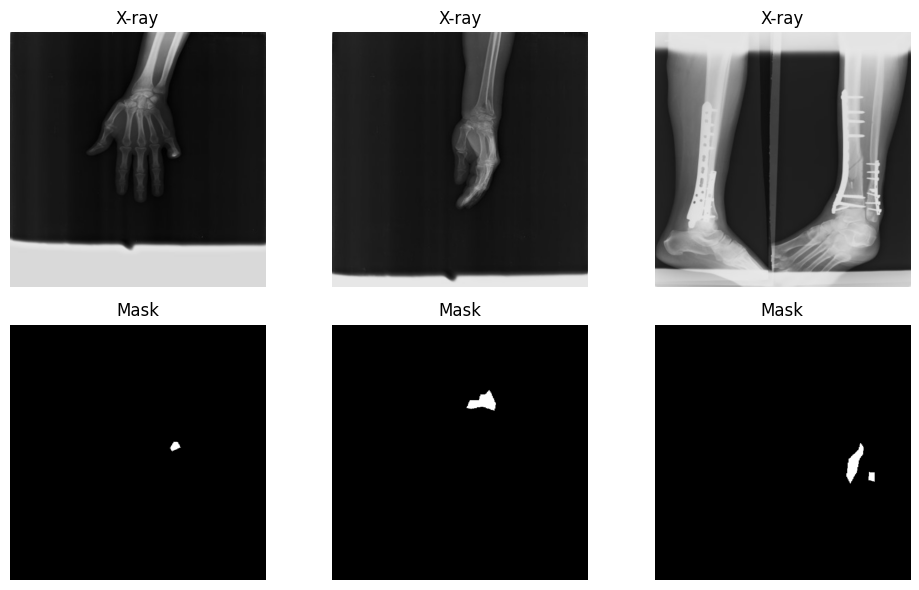

In [ ]:

images, masks = next(iter(train_loader))
fig, ax = plt.subplots(2, 3, figsize=(10, 6))
for i in range(3):
    ax[0, i].imshow(images[i].permute(1, 2, 0).numpy())
    ax[0, i].set_title("X-ray")
    ax[0, i].axis("off")

    ax[1, i].imshow(masks[i].squeeze().numpy(), cmap="gray")
    ax[1, i].set_title("Mask")
    ax[1, i].axis("off")
plt.tight_layout()
plt.show()


## Model

In [ ]:

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

def center_crop_tensor(x, target_size):
    _, _, h, w = x.shape
    target_h, target_w = target_size
    start_h = (h - target_h) // 2
    start_w = (w - target_w) // 2
    return x[:, :, start_h:start_h + target_h, start_w:start_w + target_w]

class SimpleUNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(128, 64)

        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5)
        x4 = center_crop_tensor(x4, x.shape[-2:])
        x = torch.cat([x4, x], dim=1)
        x = self.conv1(x)

        x = self.up2(x)
        x3 = center_crop_tensor(x3, x.shape[-2:])
        x = torch.cat([x3, x], dim=1)
        x = self.conv2(x)

        x = self.up3(x)
        x2 = center_crop_tensor(x2, x.shape[-2:])
        x = torch.cat([x2, x], dim=1)
        x = self.conv3(x)

        x = self.up4(x)
        x1 = center_crop_tensor(x1, x.shape[-2:])
        x = torch.cat([x1, x], dim=1)
        x = self.conv4(x)

        logits = self.outc(x)
        return logits

model = SimpleUNet(n_channels=3, n_classes=1).to(device)
print(model.__class__.__name__)


SimpleUNet


## Losses and metrics

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.contiguous().view(-1)
        targets = targets.contiguous().view(-1)
        intersection = (probs * targets).sum()
        dice = (2.0 * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return 1.0 - dice

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.bce_weight * self.bce(logits, targets) + self.dice_weight * self.dice(logits, targets)

def dice_score_from_logits(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    intersection = (preds * targets).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()

def pixel_accuracy_from_logits(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    correct_pixels = (preds == targets).float().sum()
    total_pixels = targets.numel()
    accuracy = correct_pixels / total_pixels
    return accuracy.item()

criterion = BCEDiceLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training helpers

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        #Clearing the previous gradients that were calculated.
        optimizer.zero_grad()
        logits = model(images)
        masks = center_crop_tensor(masks, logits.shape[-2:])
        loss = criterion(logits, masks)
        #Performs backward propagation by calculating the gradient of the loss.
        loss.backward()
        #Model's weights are updated
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_accuracy = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        masks = center_crop_tensor(masks, logits.shape[-2:])
        loss = criterion(logits, masks)

        running_loss += loss.item() * images.size(0)
        running_dice += dice_score_from_logits(logits, masks) * images.size(0)
        running_accuracy += pixel_accuracy_from_logits(logits, masks) * images.size(0)

    n = len(loader.dataset)
    return running_loss / n, running_dice / n, running_accuracy / n

## Train

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "val_accuracy": []
}

best_val_dice = -1

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_dice, val_accuracy = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_accuracy"].append(val_accuracy)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), MODEL_PATH)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_loss:.4f} "
        f"val_dice={val_dice:.4f} "
        f"val_accuracy={val_accuracy:.4f} "
    )

print("Best validation Dice:", best_val_dice)
print("Saved model to:", MODEL_PATH)

Epoch [1/30] train_loss=0.7037 val_loss=0.6624 val_dice=0.0000 val_accuracy=0.9963 
Epoch [2/30] train_loss=0.6424 val_loss=0.6391 val_dice=0.0000 val_accuracy=0.9961 
Epoch [3/30] train_loss=0.6237 val_loss=0.6225 val_dice=0.0000 val_accuracy=0.9952 
Epoch [4/30] train_loss=0.6109 val_loss=0.6086 val_dice=0.0000 val_accuracy=0.9963 
Epoch [5/30] train_loss=0.5973 val_loss=0.5925 val_dice=0.0000 val_accuracy=0.9963 
Epoch [6/30] train_loss=0.5866 val_loss=0.5814 val_dice=0.0000 val_accuracy=0.9962 
Epoch [7/30] train_loss=0.5773 val_loss=0.5749 val_dice=0.0000 val_accuracy=0.9963 
Epoch [8/30] train_loss=0.5681 val_loss=0.5671 val_dice=0.0511 val_accuracy=0.9953 


KeyboardInterrupt: 

## Plot training history

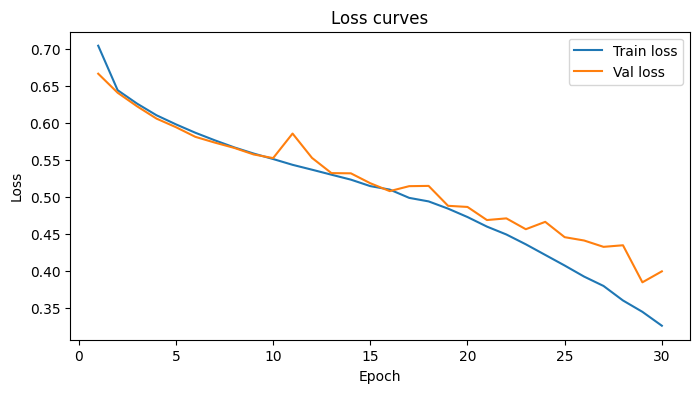

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.show()

## Evaluate on test set

In [ ]:
best_model = SimpleUNet(n_channels=3, n_classes=1).to(device)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

test_loss, test_dice, test_accuracy = evaluate(best_model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")

Test loss: 0.3786
Test Dice: 0.3037
Test Accuracy:  0.9934


## Prediction with mask + bounding box

In [ ]:

import cv2

def predict_and_plot(model, image_path, device, img_size=256, threshold=0.30, min_contour_area=20):
    model.eval()

    image = Image.open(image_path).convert('RGB')
    resized = TF.resize(image, [img_size, img_size], interpolation=InterpolationMode.BILINEAR)
    input_tensor = TF.to_tensor(resized).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        prob = torch.sigmoid(logits)

    prob_np = prob.cpu().squeeze().numpy()
    prob_np = cv2.resize(prob_np, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
    pred_np = (prob_np > threshold).astype(np.uint8)

    print("Prediction stats:")
    print("min =", float(prob_np.min()))
    print("max =", float(prob_np.max()))
    print("mean =", float(prob_np.mean()))

    contours, _ = cv2.findContours((pred_np * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    img_np = input_tensor.cpu().squeeze().permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    ax[0].imshow(img_np)
    ax[0].set_title("Original image")
    ax[0].axis("off")

    ax[1].imshow(prob_np, cmap="hot")
    ax[1].set_title("Raw predicted probability")
    ax[1].axis("off")

    ax[2].imshow(img_np)
    pred_masked = np.ma.masked_where(pred_np == 0, pred_np)
    ax[2].imshow(pred_masked, alpha=0.5, cmap="autumn")

    found_box = False
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_contour_area:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        ax[2].add_patch(rect)
        ax[2].text(x, max(y - 5, 0), 'Fracture', color='red', fontsize=12, weight='bold')
        found_box = True

    ax[2].set_title("Mask + bounding box" if found_box else "No box found")
    ax[2].axis("off")
    plt.show()


## Test on a random image from the test split

Testing on: IMG0002036.jpg
Prediction stats:
min = 0.00036275028833188117
max = 0.9553878903388977
mean = 0.004416235256940126


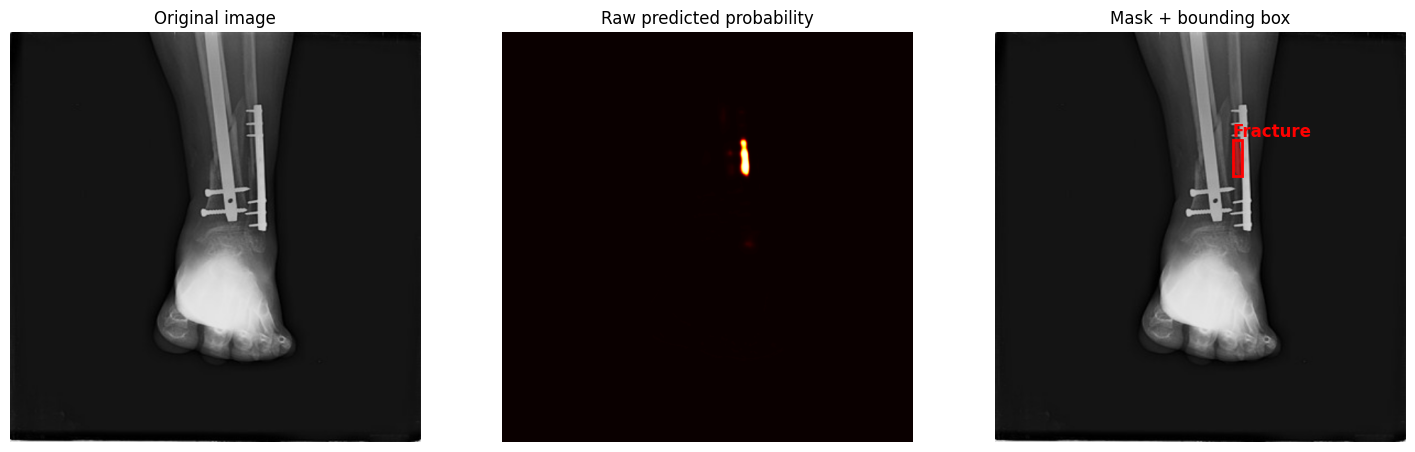

In [ ]:

if len(test_dataset) > 0:
    random_idx = random.randint(0, len(test_dataset) - 1)
    original_idx = test_dataset.indices[random_idx]
    ann = test_dataset.dataset.annotations[original_idx]
    image_name = ann['filename']
    test_image_path = os.path.join(test_dataset.dataset.images_dir, image_name)

    print("Testing on:", image_name)
    predict_and_plot(best_model, test_image_path, device, img_size=IMG_SIZE, threshold=0.30, min_contour_area=20)
else:
    print("Test dataset is empty.")


# Part 2: Bone Fracture Type Detection

The link for the dataset from Roboflow Universe for this part is : https://universe.roboflow.com/labelling-ckpec/bone-fracture-1wc2r/dataset/1

In [ ]:
!pip install ultralytics

import ultralytics
from ultralytics import YOLO
import os

ultralytics.checks()


Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 43.5/235.7 GB disk)


In [ ]:
model = YOLO('yolov8n.pt')

In [ ]:
data_path = '/content/drive/MyDrive/Bone fracture.v1i.yolov8/custom_data.yaml'

results = model.train(
    data=data_path,
    epochs=25,  # Increased epochs from 25 to 50
    imgsz=640,
    device=0,
    name='yolov8_bone_fracture'
)


Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Bone fracture.v1i.yolov8/custom_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_bone_fracture, nbs=64, nms=False, opset=None, opti

In [ ]:
# Load the best model from the training run
best_model = YOLO('runs/detect/yolov8_bone_fracture/weights/best.pt')

# Validate the model
metrics = best_model.val()


Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 3,008,963 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 24.8±7.5 MB/s, size: 28.0 KB)
val: Scanning /content/drive/MyDrive/Bone fracture.v1i.yolov8/valid/labels.cache... 395 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 395/395 78.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.7it/s 3.2s
                   all        395        407      0.368      0.426      0.356      0.299
     avulsion-fracture         28         28      0.333      0.714      0.403      0.334
closed-simple-fracture         22         22      0.586      0.818      0.821      0.693
   comminuted-fracture         43         43      0.491      0.558       0.56      0.498
compression-crush-fracture         30         30      0.775      0.833      0.815      0.763
  fra

# Part 3: Integrating both the models in one unified user-interface using Gradio


In [ ]:
!pip install ultralytics

In [ ]:
!pip install -q gradio

import gradio as gr
import torch
import cv2
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
from ultralytics import YOLO
import matplotlib.pyplot as plt

YOLO_MODEL_PATH = '/content/runs/detect/yolov8_bone_fracture/weights/best.pt'
UNET_MODEL_PATH = '/content/drive/MyDrive/Bone_Fracture_Weights/U_Net_Weight/best_fracatlas_unet.pt'

yolo_model = YOLO(YOLO_MODEL_PATH)

unet_model = SimpleUNet(n_channels=3, n_classes=1).to(device)
unet_model.load_state_dict(torch.load(UNET_MODEL_PATH, map_location=device))
unet_model.eval()

def process_unet(image_np):
    img_pil = Image.fromarray(image_np).convert('RGB')
    resized = TF.resize(img_pil, [578, 578], interpolation=InterpolationMode.BILINEAR)
    input_tensor = TF.to_tensor(resized).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = unet_model(input_tensor)
        prob = torch.sigmoid(logits)

    prob_np = prob.cpu().squeeze().numpy()
    prob_np = cv2.resize(prob_np, (578, 578), interpolation=cv2.INTER_LINEAR)
    pred_np = (prob_np > 0.30).astype(np.uint8)

    contours, _ = cv2.findContours((pred_np * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    out_img = np.array(resized)

    red_mask = np.zeros_like(out_img)
    red_mask[:,:,0] = 255
    mask_idx = pred_np > 0

    alpha = 0.5
    out_img[mask_idx] = cv2.addWeighted(out_img[mask_idx], 1 - alpha, red_mask[mask_idx], alpha, 0)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 20:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(out_img, (x, y), (x+w, y+h), (255, 0, 0), 2)
        cv2.putText(out_img, 'Fracture', (x, max(y - 5, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    return out_img

def predict_fracture(image, conf_threshold):
    if image is None:
        return None, None, "No image uploaded."

    results = yolo_model.predict(source=image, conf=conf_threshold)

    detected_classes = []
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        class_name = yolo_model.names[class_id]
        detected_classes.append(class_name)

    if detected_classes:
        fracture_types_str = ", ".join(sorted(list(set(detected_classes))))
    else:
        fracture_types_str = "No fractures detected."

    yolo_result = results[0].plot()
    yolo_result_rgb = cv2.cvtColor(yolo_result, cv2.COLOR_BGR2RGB)

    unet_result_rgb = process_unet(image)

    return unet_result_rgb, yolo_result_rgb, fracture_types_str

demo = gr.Interface(
    fn=predict_fracture,
    inputs=[
        gr.Image(type="numpy", label="Upload X-ray Image"),
        gr.Slider(minimum=0.01, maximum=1.0, value=0.10, step=0.01, label="YOLO Confidence Threshold")
    ],
    outputs=[
        gr.Image(label="UNet Prediction (Custom Weights)"),
        gr.Image(label="YOLO Prediction (Custom Weights)"),
        gr.Textbox(label="Detected Fracture Types (YOLO)")
    ],
    title="Bone Fracture Detection: UNet & YOLOv8",
    description="Upload an X-ray image to see fracture detections from both the custom UNet model and YOLOv8 side-by-side. You can adjust the YOLO confidence threshold if it misses the fracture.\n\n**Note:** The output from U-Net shows the exact location of the fracture, and the output from YOLOv8 gives us the type of bone fractures present in the X-ray image."
)

demo.launch(debug=True, share=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6c74e425237a27447b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error


0: 640x544 2 avulsion-fractures, 1 oblique-fracture, 1 spiral-fracture, 60.8ms
Speed: 2.3ms preprocess, 60.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 544)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error


0: 640x544 1 oblique-fracture, 1 spiral-fracture, 61.2ms
Speed: 4.6ms preprocess, 61.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 544)


...


0: 640x544 1 oblique-fracture, 1 spiral-fracture, 61.4ms
Speed: 3.2ms preprocess, 61.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 544)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error


0: 640x544 2 avulsion-fractures, 1 oblique-fracture, 1 spiral-fracture, 62.7ms
Speed: 3.4ms preprocess, 62.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 544)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error


0: 640x544 1 oblique-fracture, 1 spiral-fracture, 7.7ms
Speed: 3.3ms preprocess, 7.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 544)
